# Paper tables — automatic generation

Builds the four tables in the paper directly from the result JSONs:

1. **In-distribution comparison** (Small + Base sections)
2. **Cross-distribution generalization** — 10-shot system comparison
3. **Ablation 1**: LoRA vs PiSSA × attention-only vs all-layers
4. **Ablation 2**: Pretraining (ImageNet vs DINOv3) × PEFT design

Nothing is hard-coded — every number is read from `results/metrics/` (in-distribution) or `results/peft_sweep/ep60/` (cross-distribution). Parameter counts come from instantiating the model factories.

In [14]:
# ── Setup ─────────────────────────────────────────────────────────
from __future__ import annotations
import json, glob, os, re, sys
from collections import defaultdict
from pathlib import Path
from typing import Iterable, Optional

import numpy as np
import pandas as pd
from IPython.display import Markdown, display

REPO_ROOT = Path.cwd()
assert (REPO_ROOT / "results").is_dir(), f"run from repo root; got {REPO_ROOT}"
sys.path.insert(0, str(REPO_ROOT))

METRICS_DIR  = REPO_ROOT / "results" / "metrics"
EP60_DIR     = REPO_ROOT / "results" / "peft_sweep" / "ep60"
CFS_DIR      = REPO_ROOT / "results" / "cross_few_shot"

# Headline cross-dataset transfer pairs (label → (source, target)).
CROSS_PAIRS = {
    "Cross-age":         ("glasgow_young", "glasgow_mature"),
    "Cross-orientation": ("mad_sub12",     "mad_sub3"),
    "Cross-Dataset":     ("glasgow_5",     "mad_5"),
}
ABLATION_PAIR = ("glasgow_5", "mad_5")  # ablation tables use this pair

FT_SEEDS = (0, 1, 2)
EPOCHS, LR_TAG, RANK = 60, "1em4", 8

In [15]:
# ── Parameter counts (instantiate each factory at n_classes=6) ────
# Silence the timm deprecation banner during model construction.
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

from scripts.run_eval import SUPERVISED_REGISTRY
from eval.models.dinov3 import DINOv3Extractor
from eval.models.vit_imagenet import ViTImageNetExtractor

def _count(m):
    tr  = sum(p.numel() for p in m.parameters() if p.requires_grad)
    tot = sum(p.numel() for p in m.parameters())
    return tr, tot

FT_KEYS = [
    "dinov3_vits16_pissa", "dinov3_vitb16_pissa",
    "dinov3_vits16_lora",  "vit_small_imagenet_lora",
    "vit_small_imagenet_selafd", "vit_base_imagenet_selafd",
    "resnet50",
]
FROZEN_KEYS = [
    ("dinov3_vits16",      lambda: DINOv3Extractor(variant="vits16").model),
    ("vit_small_imagenet", lambda: ViTImageNetExtractor(variant="vits16").model),
    ("dinov3_vitb16",      lambda: DINOv3Extractor(variant="vitb16").model),
    ("vit_base_imagenet",  lambda: ViTImageNetExtractor(variant="vitb16").model),
]

PARAMS: dict[str, tuple[int, int]] = {}
for key in FT_KEYS:
    factory, _ = SUPERVISED_REGISTRY[key]
    PARAMS[key] = _count(factory(6))
for key, ctor in FROZEN_KEYS:
    backbone = ctor()
    PARAMS[key] = (0, sum(p.numel() for p in backbone.parameters()))

# Tidy display.
_rows = [(k, tr, tot, 100*tr/max(tot,1)) for k, (tr, tot) in PARAMS.items()]
_df = pd.DataFrame(_rows, columns=["key", "trainable", "total", "%"]).set_index("key")
_df

Loading weights: 100%|██████████| 211/211 [00:00<00:00, 5583.62it/s]
2026-06-10 14:36:41.494 | INFO     | eval.models.dinov3_lora:build_dinov3_lora:132 - DINOv3-vits16 PiSSA (r=8, alpha=16, targets=['q_proj', 'k_proj', 'v_proj', 'o_proj', 'up_proj', 'down_proj']): 663,552 trainable / 22,260,096 total params (2.98%)
Loading weights: 100%|██████████| 211/211 [00:00<00:00, 7891.13it/s]
2026-06-10 14:37:01.903 | INFO     | eval.models.dinov3_lora:build_dinov3_lora:132 - DINOv3-vitb16 PiSSA (r=8, alpha=16, targets=['q_proj', 'k_proj', 'v_proj', 'o_proj', 'up_proj', 'down_proj']): 1,327,104 trainable / 86,987,520 total params (1.53%)
Loading weights: 100%|██████████| 211/211 [00:00<00:00, 8186.92it/s]
2026-06-10 14:37:02.457 | INFO     | eval.models.dinov3_lora:build_dinov3_lora:132 - DINOv3-vits16 LoRA (r=8, alpha=16, targets=['q_proj', 'k_proj', 'v_proj', 'o_proj']): 294,912 trainable / 21,891,456 total params (1.35%)
2026-06-10 14:37:02.804 | INFO     | eval.models.vit_imagenet_lora:build

,trainable,total,%
key,,,
dinov3_vits16_pissa,665862,22262406,2.990971
dinov3_vitb16_pissa,1331718,86992134,1.530849
dinov3_vits16_lora,297222,21893766,1.357565
vit_small_imagenet_lora,223494,21889158,1.021026
vit_small_imagenet_selafd,3628806,25294470,14.346242
vit_base_imagenet_selafd,14335494,100134150,14.316289
resnet50,23520326,23520326,100.000000
dinov3_vits16,0,21596544,0.000000
vit_small_imagenet,0,21665664,0.000000


In [16]:
# ── Helpers: load result files and pull metrics ──────────────────
def _supervised(d: dict) -> Optional[tuple[float, float]]:
    sv = d.get("probes", {}).get("supervised")
    return None if not sv else (sv["mean_acc"], sv["std_acc"])

def _linear(d: dict, n_shots: object) -> Optional[float]:
    """Return the mean_acc for the requested shot count from a linear_C1.0 probe.
    Pass n_shots=None for the 'full' entry."""
    lp = d.get("probes", {}).get("linear_C1.0")
    if lp is None:
        return None
    if isinstance(lp, dict):           # cross_eval-style: single point
        return lp.get("acc")
    for e in lp:
        if e["n_shots"] == n_shots:
            return e["mean_acc"]
    return None

def _load(path: Path) -> Optional[dict]:
    return json.loads(path.read_text()) if path.exists() else None

def _latest(pattern: str) -> Optional[Path]:
    cand = sorted(Path().glob(pattern))
    return cand[-1] if cand else None

def in_dist_ft(key: str, dataset: str) -> Optional[tuple[float, float]]:
    """Read in-distribution supervised CV acc for an FT method."""
    d = _load(METRICS_DIR / f"{key}_ep{EPOCHS}_lr{LR_TAG}_s42__{dataset}.json")
    return None if d is None else _supervised(d)

def in_dist_frozen(key: str, dataset: str) -> Optional[tuple[float, float]]:
    """Read in-distribution linear-probe (frozen) result. Prefers the
    deterministic-named file, falls back to the most recent timestamped one."""
    det = METRICS_DIR / f"{key}__{dataset}.json"
    if det.exists():
        d = _load(det)
    else:
        d = None
        cand = sorted(METRICS_DIR.glob(f"{key}__{dataset}__*.json"))
        if cand:
            d = _load(cand[-1])
    if d is None:
        return None
    lp = d["probes"]["linear_C1.0"]
    return (lp["mean_acc"], lp["std_acc"])

In [17]:
# ── Cross-dataset helpers (PEFT sweep + frozen + ResNet50) ────────
def _peft_seeds(file_glob: str, predicate) -> dict[int, dict]:
    """Collect {seed: per_shot_dict} from peft_sweep files matching the
    glob, keeping only those for which `predicate(sweep_tag)` is True."""
    out: dict[int, dict] = {}
    for fp in EP60_DIR.glob(file_glob):
        d = json.loads(fp.read_text())
        sw = d.get("sweep", {})
        if not predicate(sw):
            continue
        seed = sw["seed"]
        out[seed] = {e["n_shots"]: e["mean_acc"] for e in d["probes"]["linear_C1.0"]}
    return out

def cross_peft(method: str, targets: str, src: str, tgt: str,
               shot: object) -> Optional[tuple[float, float]]:
    """Aggregate the 3-seed mean/std for a PEFT method at one shot level.
    Uses a permissive glob and lets the sweep-tag predicate do the filtering
    (file naming for `lora_in`/`pissa_in` reorders the method tokens, so a
    method-specific glob would miss them)."""
    seeds = _peft_seeds(
        f"vits16_*_s*__{src}__{tgt}.json",
        lambda s: (
            s.get("method") == method
            and s.get("epochs") == EPOCHS
            and s.get("lr") == 1e-4
            and s.get("rank") == RANK
            and s.get("targets") == targets
        ),
    )
    vs = [seeds[s][shot] for s in sorted(seeds) if shot in seeds[s]]
    return (float(np.mean(vs)), float(np.std(vs, ddof=0))) if vs else None

def cross_selafd(src: str, tgt: str, shot: object) -> Optional[tuple[float, float]]:
    seeds = _peft_seeds(
        f"vits16_vit_selafd_lr{LR_TAG}_s*__{src}__{tgt}.json",
        lambda s: s.get("method") == "selafd" and s.get("epochs") == EPOCHS
                  and s.get("lr") == 1e-4,
    )
    vs = [seeds[s][shot] for s in sorted(seeds) if shot in seeds[s]]
    return (float(np.mean(vs)), float(np.std(vs, ddof=0))) if vs else None

def cross_resnet(src: str, tgt: str, shot: object) -> Optional[tuple[float, float]]:
    seeds: dict[int, float] = {}
    for fp in CFS_DIR.glob(f"resnet50_s*_ft_{src}__{tgt}__*.json"):
        m = re.match(r"resnet50_s(\d)_ft_", fp.name)
        if not m: continue
        d = json.loads(fp.read_text())
        v = _linear(d, shot)
        if v is not None:
            seeds[int(m.group(1))] = v
    vs = list(seeds.values())
    return (float(np.mean(vs)), float(np.std(vs, ddof=0))) if vs else None

def cross_frozen(backbone_key: str, src: str, tgt: str, shot: object) -> Optional[float]:
    """Read the single deterministic frozen run for a (src, tgt) pair.
    backbone_key is the bare extractor key (e.g. 'dinov3_vits16'); the
    glob template adds the '_frozen_frozen_' that run_cross_few_shot.py uses
    when --freeze is set (model_name has '_frozen' suffix, plus the 'frozen_'
    tag in the display name)."""
    cand = sorted(CFS_DIR.glob(f"{backbone_key}_frozen_frozen_{src}__{tgt}__*.json"))
    if not cand:
        return None
    return _linear(json.loads(cand[-1].read_text()), shot)


In [18]:
# ── Display helpers ───────────────────────────────────────────────
def fmt_pair(pair: Optional[tuple[float, float]]) -> str:
    return "—" if pair is None else f"{pair[0]*100:.2f} ({pair[1]*100:.2f})"

def fmt_single(v: Optional[float]) -> str:
    return "—" if v is None else f"{v*100:.2f}"

def fmt_params(trainable: int, total: int) -> tuple[str, str]:
    if trainable == 0:
        return ("~0 M (probe only)", f"{total/1e6:.2f} M")
    if trainable >= 1e6:
        tr_s = f"{trainable/1e6:.2f} M ({100*trainable/total:.2f}%)"
    else:
        tr_s = f"{trainable/1e3:.0f} K ({100*trainable/total:.2f}%)"
    return (tr_s, f"{total/1e6:.2f} M")

## Table 1 — In-distribution comparison

Mean (std) over 5 subject-disjoint StratifiedGroupKFold folds, seed=42, ep=60, lr=1e-4.
FT rows: supervised CV accuracy; frozen rows: linear-probe accuracy on cached features.

In [19]:
# Layout follows the screenshot: Small section then Base section.
T1_ROWS = [
    # (label, key, kind)  kind ∈ {'ft', 'frozen'}
    ("Small (~22-25M total)", None, "hdr"),
    ("ViT-S ImageNet (frozen)",         "vit_small_imagenet",        "frozen"),
    ("DINOv3-S (frozen)",               "dinov3_vits16",             "frozen"),
    ("ResNet50 (ft)",                   "resnet50",                  "ft"),
    ("SelaFD ViT-S",                    "vit_small_imagenet_selafd", "ft"),
    ("ViT-S + LoRA",                    "vit_small_imagenet_lora",   "ft"),
    ("DINOv3-S + PiSSA (Ours)",         "dinov3_vits16_pissa",       "ft"),
    ("Base (~86-100M total)", None, "hdr"),
    ("ViT-B ImageNet (frozen)",         "vit_base_imagenet",         "frozen"),
    ("DINOv3-B (frozen)",               "dinov3_vitb16",             "frozen"),
    ("SelaFD ViT-B",                    "vit_base_imagenet_selafd",  "ft"),
    ("DINOv3-B + PiSSA (Ours)",         "dinov3_vitb16_pissa",       "ft"),
]

records = []
for label, key, kind in T1_ROWS:
    if kind == "hdr":
        records.append({"Method": f"*{label}*", "Trainable": "", "Total": "", "Glasgow": "", "MAD": ""})
        continue
    tr_s, tot_s = fmt_params(*PARAMS[key])
    g = in_dist_ft(key, "glasgow") if kind == "ft" else in_dist_frozen(key, "glasgow")
    m = in_dist_ft(key, "mad")     if kind == "ft" else in_dist_frozen(key, "mad")
    records.append({
        "Method":    label,
        "Trainable": tr_s,
        "Total":     tot_s,
        "Glasgow":   fmt_pair(g),
        "MAD":       fmt_pair(m),
    })
T1 = pd.DataFrame(records)
display(Markdown(T1.to_markdown(index=False)))
T1

| Method                  | Trainable         | Total    | Glasgow      | MAD          |
|:------------------------|:------------------|:---------|:-------------|:-------------|
| *Small (~22-25M total)* |                   |          |              |              |
| ViT-S ImageNet (frozen) | ~0 M (probe only) | 21.67 M  | 87.16 (1.58) | 62.43 (0.90) |
| DINOv3-S (frozen)       | ~0 M (probe only) | 21.60 M  | 86.35 (1.52) | 72.25 (1.06) |
| ResNet50 (ft)           | 23.52 M (100.00%) | 23.52 M  | 94.57 (1.08) | 97.21 (0.55) |
| SelaFD ViT-S            | 3.63 M (14.35%)   | 25.29 M  | 90.77 (1.19) | 94.47 (0.95) |
| ViT-S + LoRA            | 223 K (1.02%)     | 21.89 M  | 91.92 (1.20) | 92.17 (0.95) |
| DINOv3-S + PiSSA (Ours) | 666 K (2.99%)     | 22.26 M  | 92.79 (1.37) | 96.62 (0.74) |
| *Base (~86-100M total)* |                   |          |              |              |
| ViT-B ImageNet (frozen) | ~0 M (probe only) | 85.80 M  | 88.26 (2.03) | 65.32 (1.00) |
| DINOv3-B (frozen)       | ~0 M (probe only) | 85.66 M  | 87.12 (1.28) | 74.85 (0.94) |
| SelaFD ViT-B            | 14.34 M (14.32%)  | 100.13 M | 92.06 (0.72) | 95.69 (0.86) |
| DINOv3-B + PiSSA (Ours) | 1.33 M (1.53%)    | 86.99 M  | 93.85 (1.15) | 97.10 (0.58) |

,Method,Trainable,Total,Glasgow,MAD
0,*Small (~22-25M total)*,,,,
1,ViT-S ImageNet (frozen),~0 M (probe only),21.67 M,87.16 (1.58),62.43 (0.90)
2,DINOv3-S (frozen),~0 M (probe only),21.60 M,86.35 (1.52),72.25 (1.06)
3,ResNet50 (ft),23.52 M (100.00%),23.52 M,94.57 (1.08),97.21 (0.55)
4,SelaFD ViT-S,3.63 M (14.35%),25.29 M,90.77 (1.19),94.47 (0.95)
5,ViT-S + LoRA,223 K (1.02%),21.89 M,91.92 (1.20),92.17 (0.95)
6,DINOv3-S + PiSSA (Ours),666 K (2.99%),22.26 M,92.79 (1.37),96.62 (0.74)
7,*Base (~86-100M total)*,,,,
8,ViT-B ImageNet (frozen),~0 M (probe only),85.80 M,88.26 (2.03),65.32 (1.00)
9,DINOv3-B (frozen),~0 M (probe only),85.66 M,87.12 (1.28),74.85 (0.94)


## Table 2 — Cross-distribution generalization (10-shot)

Linear-probe accuracy on target with 10 shots per class. Mean (std) over 3 FT seeds for fine-tuned methods, single deterministic run for frozen rows.

* Cross-age = `glasgow_young → glasgow_mature`
* Cross-orientation = `mad_sub12 → mad_sub3`
* Cross-Dataset = `glasgow_5 → mad_5`

In [20]:
SHOT = 10

T2_ROWS = [
    # backbone_key is the bare extractor name; cross_frozen() adds the
    # _frozen_frozen_ suffix that matches the on-disk file naming.
    ("DINOv3 ViT-S (frozen)",        "frozen",  "dinov3_vits16"),
    ("ViT-S ImageNet (frozen)",      "frozen",  "vit_small_imagenet"),
    ("ResNet50 (ft)",                "resnet",  None),
    ("SelaFD (ViT-S ImageNet)",      "selafd",  None),
    ("ImageNet ViT-S + LoRA",        "peft",    ("lora_in", "attn")),
    ("DINOv3 ViT-S + PiSSA (Ours)",  "peft",    ("pissa",   "all")),
]

records = []
for label, kind, spec in T2_ROWS:
    row = {"Method": label}
    for col, (src, tgt) in CROSS_PAIRS.items():
        if kind == "frozen":
            row[col] = fmt_single(cross_frozen(spec, src, tgt, SHOT))
        elif kind == "resnet":
            row[col] = fmt_pair(cross_resnet(src, tgt, SHOT))
        elif kind == "selafd":
            row[col] = fmt_pair(cross_selafd(src, tgt, SHOT))
        else:  # peft
            method, targets = spec
            row[col] = fmt_pair(cross_peft(method, targets, src, tgt, SHOT))
    records.append(row)
T2 = pd.DataFrame(records)
display(Markdown(T2.to_markdown(index=False)))
T2


| Method                      | Cross-age    | Cross-orientation   | Cross-Dataset   |
|:----------------------------|:-------------|:--------------------|:----------------|
| DINOv3 ViT-S (frozen)       | 64.68        | 39.22               | 64.86           |
| ViT-S ImageNet (frozen)     | 66.25        | 29.28               | 55.56           |
| ResNet50 (ft)               | 79.12 (0.32) | 79.15 (0.14)        | 33.57 (3.55)    |
| SelaFD (ViT-S ImageNet)     | 75.34 (1.01) | 75.88 (0.52)        | 58.25 (0.95)    |
| ImageNet ViT-S + LoRA       | 77.22 (0.78) | 75.60 (1.19)        | 57.45 (1.00)    |
| DINOv3 ViT-S + PiSSA (Ours) | 77.46 (0.29) | 81.07 (0.65)        | 67.70 (0.48)    |

,Method,Cross-age,Cross-orientation,Cross-Dataset
0,DINOv3 ViT-S (frozen),64.68,39.22,64.86
1,ViT-S ImageNet (frozen),66.25,29.28,55.56
2,ResNet50 (ft),79.12 (0.32),79.15 (0.14),33.57 (3.55)
3,SelaFD (ViT-S ImageNet),75.34 (1.01),75.88 (0.52),58.25 (0.95)
4,ImageNet ViT-S + LoRA,77.22 (0.78),75.60 (1.19),57.45 (1.00)
5,DINOv3 ViT-S + PiSSA (Ours),77.46 (0.29),81.07 (0.65),67.70 (0.48)


## Table 3 — Ablation 1: LoRA vs PiSSA × attention-only vs all-layers

All cells: 10-shot linear probe on `glasgow_5 → mad_5`, mean (std) over 3 seeds, ep=60, lr=1e-4, r=8.

In [21]:
SRC, TGT = ABLATION_PAIR
rows = []
for tgt_mods in ("attn", "all"):
    rows.append({
        "":     "Attention only" if tgt_mods == "attn" else "All layers",
        "LoRA":  fmt_pair(cross_peft("lora",  tgt_mods, SRC, TGT, SHOT)),
        "PiSSA": fmt_pair(cross_peft("pissa", tgt_mods, SRC, TGT, SHOT)),
    })
T3 = pd.DataFrame(rows)
display(Markdown(T3.to_markdown(index=False)))
T3

|                | LoRA         | PiSSA        |
|:---------------|:-------------|:-------------|
| Attention only | 66.08 (1.67) | 63.03 (3.28) |
| All layers     | 64.95 (1.91) | 67.70 (0.48) |

,,LoRA,PiSSA
0,Attention only,66.08 (1.67),63.03 (3.28)
1,All layers,64.95 (1.91),67.70 (0.48)


## Table 4 — Ablation 2: Pretraining × PEFT design

10-shot linear probe on `glasgow_5 → mad_5`. Frozen cells are deterministic (single run); FT cells are mean (std) over 3 seeds.

In [22]:
rows = [
    {
        "":              "Frozen",
        "ImageNet ViT-S": fmt_single(cross_frozen("vit_small_imagenet", SRC, TGT, SHOT)),
        "DINOv3 ViT-S":   fmt_single(cross_frozen("dinov3_vits16",      SRC, TGT, SHOT)),
    },
    {
        "":              "+ LoRA (attn)",
        "ImageNet ViT-S": fmt_pair(cross_peft("lora_in", "attn", SRC, TGT, SHOT)),
        "DINOv3 ViT-S":   fmt_pair(cross_peft("lora",    "attn", SRC, TGT, SHOT)),
    },
    {
        "":              "+ PiSSA (all layers)",
        "ImageNet ViT-S": fmt_pair(cross_peft("pissa_in", "all", SRC, TGT, SHOT)),
        "DINOv3 ViT-S":   fmt_pair(cross_peft("pissa",    "all", SRC, TGT, SHOT)),
    },
]
T4 = pd.DataFrame(rows)
display(Markdown(T4.to_markdown(index=False)))
T4


|                      | ImageNet ViT-S   | DINOv3 ViT-S   |
|:---------------------|:-----------------|:---------------|
| Frozen               | 55.56            | 64.86          |
| + LoRA (attn)        | 57.45 (1.00)     | 66.08 (1.67)   |
| + PiSSA (all layers) | 58.41 (1.02)     | 67.70 (0.48)   |

,,ImageNet ViT-S,DINOv3 ViT-S
0,Frozen,55.56,64.86
1,+ LoRA (attn),57.45 (1.00),66.08 (1.67)
2,+ PiSSA (all layers),58.41 (1.02),67.70 (0.48)


## Figure — Robustness grouped bar chart

Grouped bar chart comparing each method's accuracy across columns (in-distribution → cross-distribution). The exact set of methods matches Table 2.

Three modes:
* **Minimal** (default): `in-dist (Glasgow)` → `cross-dataset (Glasgow → MAD)`. Reproduces the manuscript figure.
* **Mid**: adds `cross-orientation (sub12 → sub3)` between the two minimal columns.
* **Full**: includes the MAD in-distribution column and all three cross-distribution columns.

Colors: **Ours** in green, **ResNet50** in red, **DINOv3 frozen** in blue, all others in light gray. Value labels are drawn on the highlighted bars; legend at the top.

In [ ]:
# ── Method spec for the figure (mirrors Table 2 method set) ─────
# Each entry pins how to look up in-distribution AND cross-dataset numbers
# for that method.  color = 'auto' → gray fallback in the plot.
METHODS_FIG = [
    # Highlights
    {"label": "Ours (DINOv3 + PiSSA)",
     "in_dist": ("ft", "dinov3_vits16_pissa"),
     "cross":   ("peft", "pissa", "all"),
     "color":   "#2ca02c"},                          # green
    {"label": "ResNet50 (full FT)",
     "in_dist": ("ft", "resnet50"),
     "cross":   ("resnet",),
     "color":   "#d62728"},                          # red
    {"label": "DINOv3 frozen",
     "in_dist": ("frozen", "dinov3_vits16"),
     "cross":   ("frozen", "dinov3_vits16"),
     "color":   "#1f77b4"},                          # blue

    # Greys
    {"label": "ImageNet ViT-S + LoRA",
     "in_dist": ("ft", "vit_small_imagenet_lora"),
     "cross":   ("peft", "lora_in", "attn"),
     "color":   "auto"},
    {"label": "SelaFD",
     "in_dist": ("ft", "vit_small_imagenet_selafd"),
     "cross":   ("selafd",),
     "color":   "auto"},
    {"label": "ViT-S frozen (IN)",
     "in_dist": ("frozen", "vit_small_imagenet"),
     "cross":   ("frozen", "vit_small_imagenet"),
     "color":   "auto"},
]


# ── Column getters: each returns (method_spec) → accuracy in % or None ─
def col_in_dist(dataset: str):
    def getter(m):
        kind, key = m["in_dist"]
        p = in_dist_ft(key, dataset) if kind == "ft" else in_dist_frozen(key, dataset)
        return p[0] * 100 if p else None
    return getter

def col_cross(src: str, tgt: str, shot: object = 10):
    def getter(m):
        c = m["cross"]
        if c[0] == "frozen":
            v = cross_frozen(c[1], src, tgt, shot)
            return v * 100 if v is not None else None
        if c[0] == "resnet":
            p = cross_resnet(src, tgt, shot)
            return p[0] * 100 if p else None
        if c[0] == "selafd":
            p = cross_selafd(src, tgt, shot)
            return p[0] * 100 if p else None
        if c[0] == "peft":
            _, method, targets = c
            p = cross_peft(method, targets, src, tgt, shot)
            return p[0] * 100 if p else None
        return None
    return getter


# ── Column presets ───────────────────────────────────────────────
COLS_MINIMAL = [
    ("in-distribution\n(Glasgow)",     col_in_dist("glasgow")),
    ("cross-dataset\n(Glasgow → MAD)", col_cross("glasgow_5", "mad_5")),
]

# Mid: tells the story across one easy and one hard cross-distribution column.
COLS_MID = [
    ("in-distribution\n(Glasgow)",       col_in_dist("glasgow")),
    ("cross-orientation\n(sub12 → sub3)",col_cross("mad_sub12", "mad_sub3")),
    ("cross-dataset\n(Glasgow → MAD)",   col_cross("glasgow_5", "mad_5")),
]

COLS_FULL = [
    ("in-dist\n(Glasgow)",           col_in_dist("glasgow")),
    ("in-dist\n(MAD)",               col_in_dist("mad")),
    ("cross-age\n(young → mature)",  col_cross("glasgow_young", "glasgow_mature")),
    ("cross-orient.\n(sub12 → sub3)",col_cross("mad_sub12", "mad_sub3")),
    ("cross-dataset\n(Glasgow → MAD)", col_cross("glasgow_5", "mad_5")),
]


# ── Plot helper: grouped bar chart ───────────────────────────────
import matplotlib.pyplot as plt

def plot_robustness(columns, methods=METHODS_FIG, figsize=(9.5, 5.0), title=None,
                    show_values: bool = True,
                    value_subset: str = "highlight",
                    legend_loc: str = "top",
                    group_width: float = 0.85,
                    y_min: float = 0.0):
    """Grouped bar chart for cross-distribution robustness.

    columns: list of (x_label, getter_fn) — one group of bars per entry.
    methods: list of method spec dicts (see METHODS_FIG).
        Bar ordering within each group follows the order of `methods`.
    show_values: draw the numeric value above each bar.
    value_subset: 'highlight' → label highlighted bars only;
                  'all'       → label every bar.
    legend_loc:  'top' | 'right' | 'none'.
    group_width: total fraction of unit x-spacing occupied by one group.
    y_min: lower y-axis bound (0 is the honest choice for bars).
    """
    fig, ax = plt.subplots(figsize=figsize)
    n_cols = len(columns)

    # Gather series in METHODS_FIG order (preserve user-supplied ordering for the legend).
    series = []
    for m in methods:
        ys = [getter(m) for _, getter in columns]
        if any(y is None for y in ys):
            missing = [c for (c, _), y in zip(columns, ys) if y is None]
            print(f"  [warn] skipping '{m['label']}' — missing column(s): {missing}")
            continue
        series.append((m, ys))

    n_methods = len(series)
    bar_width = group_width / n_methods
    x = np.arange(n_cols)

    # Draw bars.
    for i, (m, ys) in enumerate(series):
        offset = (i - n_methods / 2 + 0.5) * bar_width
        is_highlight = m["color"] != "auto"
        color = m["color"] if is_highlight else "#9a9a9a"
        alpha = 1.0 if is_highlight else 0.55
        bars = ax.bar(x + offset, ys, width=bar_width * 0.92,
                      color=color, alpha=alpha,
                      label=m["label"], edgecolor="white", linewidth=0.4,
                      zorder=2 if is_highlight else 1)

        if show_values and (value_subset == "all" or is_highlight):
            label_color = color if is_highlight else "#5a5a5a"
            weight = "bold" if is_highlight else "normal"
            for bar, y in zip(bars, ys):
                ax.text(bar.get_x() + bar.get_width() / 2, y + 0.7, f"{y:.1f}",
                        ha="center", va="bottom",
                        fontsize=7.5, color=label_color, fontweight=weight)

    # X-axis ticks + labels.
    ax.set_xticks(x)
    ax.set_xticklabels([label for label, _ in columns])
    ax.set_ylabel("accuracy (%)")
    if title:
        ax.set_title(title)

    # Cosmetic frame: top/right/bottom spines off, x ticks invisible.
    for side in ("top", "right", "bottom"):
        ax.spines[side].set_visible(False)
    ax.tick_params(axis="x", which="both", bottom=False, top=False, pad=8)

    # Y-axis: start at y_min, headroom above tallest bar so value labels don't clip.
    max_y = max((y for _, ys in series for y in ys), default=100)
    ax.set_ylim(y_min, max_y + 6)

    # Horizontal gridlines (drawn behind bars).
    ax.grid(axis="y", linewidth=0.4, alpha=0.45)
    ax.set_axisbelow(True)

    # Subtle vertical separators between consecutive groups.
    for i in range(n_cols - 1):
        ax.axvline(x[i] + 0.5, color="#d0d0d0", linewidth=0.6, alpha=0.6, zorder=0)

    # Legend.
    if legend_loc == "top":
        ncol = min(4, n_methods)
        ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.02),
                  ncol=ncol, frameon=False, fontsize=9,
                  handlelength=1.4, columnspacing=1.4)
    elif legend_loc == "right":
        ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5),
                  frameon=False, fontsize=9, handlelength=1.4)

    plt.tight_layout()
    return fig


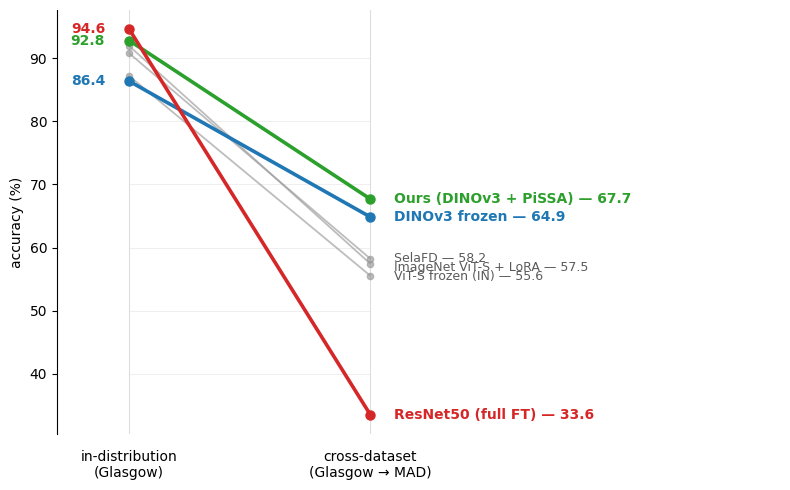

In [29]:
# Minimal mode — manuscript-style figure
fig = plot_robustness(COLS_MINIMAL)
fig.savefig("paper_figure_robustness_minimal.pdf", bbox_inches="tight")
plt.show()


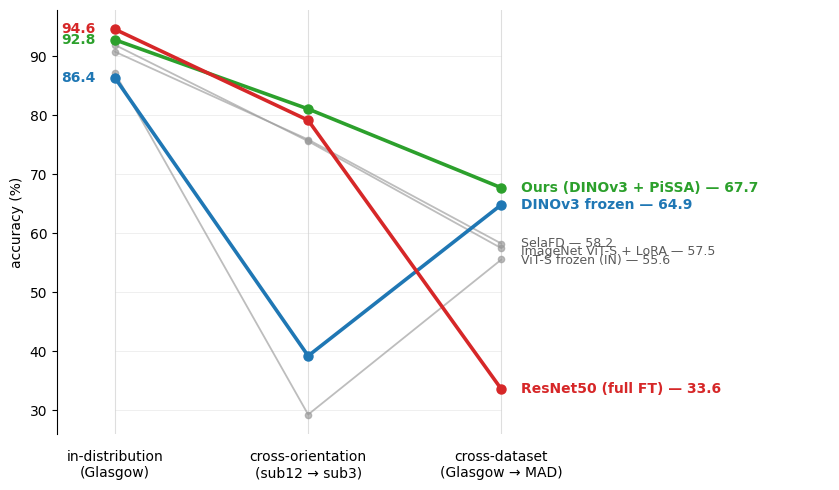

In [30]:
# Mid mode — Glasgow in-dist + cross-orientation + cross-dataset (3 columns).
fig = plot_robustness(COLS_MID, figsize=(8.5, 5.0))
fig.savefig("paper_figure_robustness_mid.pdf", bbox_inches="tight")
plt.show()


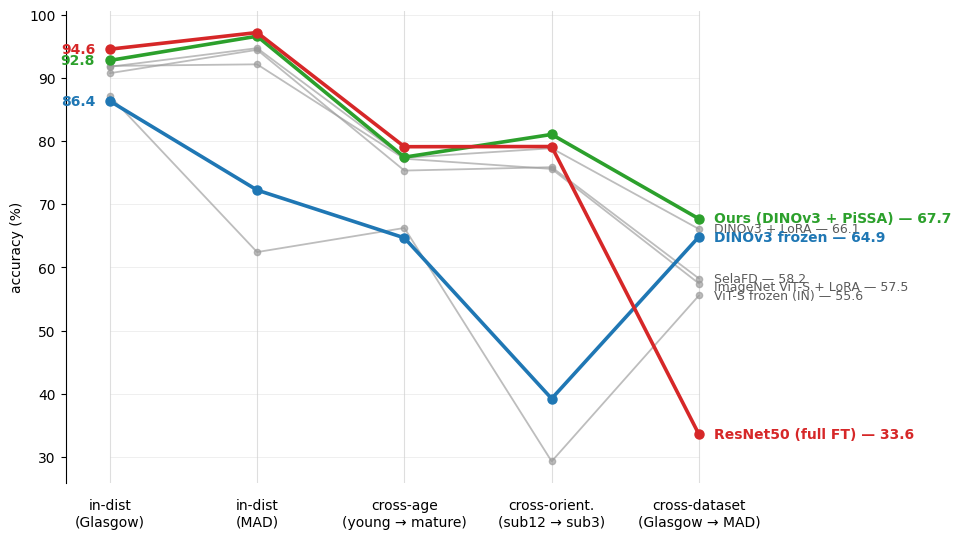

In [26]:
# Full mode — all 5 columns (Glasgow in-dist, MAD in-dist, 3 cross pairs).
fig = plot_robustness(COLS_FULL, figsize=(10.0, 5.5))
fig.savefig("paper_figure_robustness_full.pdf", bbox_inches="tight")
plt.show()


## (Optional) LaTeX export for paper inclusion

Run the cell below to dump each table to LaTeX `tabular` form.

In [27]:
for name, df in [("T1 in-distribution", T1),
                 ("T2 cross-dist (10-shot)", T2),
                 ("T3 ablation 1", T3),
                 ("T4 ablation 2", T4)]:
    print(f"% ── {name} ─────────────────────────────────")
    print(df.to_latex(index=False, escape=False))
    print()

% ── T1 in-distribution ─────────────────────────────────
\begin{tabular}{lllll}
\toprule
Method & Trainable & Total & Glasgow & MAD \\
\midrule
*Small (~22-25M total)* &  &  &  &  \\
ViT-S ImageNet (frozen) & ~0 M (probe only) & 21.67 M & 87.16 (1.58) & 62.43 (0.90) \\
DINOv3-S (frozen) & ~0 M (probe only) & 21.60 M & 86.35 (1.52) & 72.25 (1.06) \\
ResNet50 (ft) & 23.52 M (100.00%) & 23.52 M & 94.57 (1.08) & 97.21 (0.55) \\
SelaFD ViT-S & 3.63 M (14.35%) & 25.29 M & 90.77 (1.19) & 94.47 (0.95) \\
ViT-S + LoRA & 223 K (1.02%) & 21.89 M & 91.92 (1.20) & 92.17 (0.95) \\
DINOv3-S + PiSSA (Ours) & 666 K (2.99%) & 22.26 M & 92.79 (1.37) & 96.62 (0.74) \\
*Base (~86-100M total)* &  &  &  &  \\
ViT-B ImageNet (frozen) & ~0 M (probe only) & 85.80 M & 88.26 (2.03) & 65.32 (1.00) \\
DINOv3-B (frozen) & ~0 M (probe only) & 85.66 M & 87.12 (1.28) & 74.85 (0.94) \\
SelaFD ViT-B & 14.34 M (14.32%) & 100.13 M & 92.06 (0.72) & 95.69 (0.86) \\
DINOv3-B + PiSSA (Ours) & 1.33 M (1.53%) & 86.99 M & 93.85 